In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 18.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [37]:
import nltk
nltk.data.path.append('/Users/marinaashurkina/nltk_data')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/marinaashurkina/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [4]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 17.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd # импортируем библиотеку pandas

df = pd.read_csv('../data/chatgpt_reviews_clean_balanced.csv') # загружаем CSV-файл в DataFrame

In [ ]:
df.head() # смотрим как выглядит корпус


,content,score
0,"I would give this 5 star, but one key flaw it ...",1
1,This is a completely useless app. Don't downlo...,1
2,used to be good and helpful but it is now all ...,1
3,fi7dhc 88 is le ga tx existing seats height ya...,1
4,when I needed it most it says you have reached...,1


In [ ]:
len(df) # получаем количество строк в DataFrame

4620

Смотрим на распределение оценок.

In [ ]:
df['score'].value_counts() # считаем, сколько раз встречается каждое значение в столбце 'score'

score
5    1998
1    1864
2     446
4     312
Name: count, dtype: int64

In [ ]:
df['content'].sample(5, random_state=42) # случайно выбираем 5 строк из столбца 'content' (с фиксированным seed для повторяемости)

776     I am giving it 0 but I can't add 0 stars becau...
1666    good ai until you run out of messages for 5.3 ...
1728    there are lots of limits and errors too i beli...
23            errors and problems to on paid subscription
3337    This app is a therapist and a friend i never h...
Name: content, dtype: object

Добавим метки positive / negative

In [ ]:
df['label'] = df['score'].apply(lambda x: 'negative' if x in [1,2] else 'positive') # создаём столбец 'label': 1–2 → negative, иначе → positive

Длина отзывов.

In [ ]:
df['length'] = df['content'].str.len() # создаём столбец с длиной текста в 'content'
df.groupby('label')['length'].mean() # считаем среднюю длину текста для каждой категории 'label'

label
negative    138.070996
positive     70.472727
Name: length, dtype: float64

Смотрим на частотность слов в корпусе

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import nltk # импортируем библиотеку nltk для обработки текста
nltk.download('punkt') # скачиваем набор для токенизации текста
nltk.download('stopwords') # скачиваем список стоп-слов

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/marinaashurkina/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/marinaashurkina/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords # импортируем стоп-слова
from nltk.tokenize import wordpunct_tokenize # импортируем токенизатор

stop_words = set(stopwords.words('english')) # создаём набор английских стоп-слов

def preprocess(text):
    tokens = wordpunct_tokenize(text.lower()) # приводим к нижнему регистру и разбиваем на токены
    tokens = [w for w in tokens if w.isalpha()] # оставляем только слова (без цифр и символов)
    tokens = [w for w in tokens if w not in stop_words] # убираем стоп-слова
    return tokens

df['tokens'] = df['content'].apply(preprocess) # применяем функцию к столбцу 'content' и сохраняем результат

Смотрим на частотность слов

In [ ]:
from collections import Counter # импортируем класс для подсчёта частоты элементов

neg_tokens = [] # список для токенов негативных отзывов
pos_tokens = [] # список для токенов позитивных отзывов

for tokens, label in zip(df['tokens'], df['label']): 
    if label == 'negative':
        neg_tokens.extend(tokens) # добавляем токены в список негативных
    else:
        pos_tokens.extend(tokens) # добавляем токены в список позитивных

neg_freq = Counter(neg_tokens) # считаем частоты слов для негативных отзывов
pos_freq = Counter(pos_tokens) # считаем частоты слов для позитивных отзывов

In [ ]:
print("Negative:", neg_freq.most_common(20)) # 20 самых частых слов в негативных отзывах
print("Positive:", pos_freq.most_common(20)) # 20 самых частых слов в позитивных отзывах

Negative: [('app', 805), ('ai', 355), ('like', 321), ('chat', 308), ('chatgpt', 284), ('time', 269), ('even', 258), ('use', 242), ('wrong', 235), ('good', 234), ('bad', 180), ('information', 166), ('gpt', 165), ('answer', 159), ('give', 152), ('answers', 151), ('get', 136), ('want', 135), ('one', 131), ('better', 131)]
Positive: [('app', 920), ('good', 533), ('best', 395), ('chatgpt', 264), ('helpful', 253), ('love', 238), ('like', 228), ('ai', 202), ('chat', 181), ('use', 167), ('nice', 153), ('useful', 152), ('really', 145), ('help', 140), ('great', 133), ('gpt', 125), ('helps', 116), ('much', 107), ('amazing', 89), ('time', 86)]


Уберем app, chat, ai, gpt

In [88]:
noise = {'app', 'chat', 'chatgpt', 'gpt', 'ai'}

neg_clean = Counter({k: v for k, v in neg_freq.items() if k not in noise}) # убираем шум из негативных 
pos_clean = Counter({k: v for k, v in pos_freq.items() if k not in noise}) # убираем шум из позитивных 

print("Negative:", neg_clean.most_common(20)) #  топ 20 слов без шума (негатив)
print("Positive:", pos_clean.most_common(20)) #  топ 20 слов без шума (позитив)

Negative: [('like', 321), ('time', 269), ('even', 258), ('use', 242), ('wrong', 235), ('good', 234), ('bad', 180), ('information', 166), ('answer', 159), ('give', 152), ('answers', 151), ('get', 136), ('want', 135), ('one', 131), ('better', 131), ('please', 125), ('much', 124), ('worst', 123), ('ask', 122), ('using', 119)]
Positive: [('good', 533), ('best', 395), ('helpful', 253), ('love', 238), ('like', 228), ('use', 167), ('nice', 153), ('useful', 152), ('really', 145), ('help', 140), ('great', 133), ('helps', 116), ('much', 107), ('amazing', 89), ('time', 86), ('easy', 85), ('work', 84), ('one', 83), ('give', 82), ('ever', 79)]


Сделаем визаулизацию топовых слов в позитивных и негативных отзывах

In [ ]:
all_words = set(neg_clean.keys()).union(set(pos_clean.keys())) # объединяем все уникальные слова

rows = []

for word in all_words:
    neg = neg_clean.get(word, 0) # берём частоту слова в негативе (или 0)
    pos = pos_clean.get(word, 0) # берём частоту слова в позитиве (или 0)
    rows.append((word, neg, pos)) # добавляем строку (слово, негатив, позитив)

df_words = pd.DataFrame(rows, columns=['word', 'neg', 'pos']) # создаём DataFrame из списка
df_words['diff'] = df_words['neg'] - df_words['pos'] # считаем разницу частот

In [ ]:
top_neg = df_words.sort_values(by='diff', ascending=False).head(10) # берём топ-10 слов с наибольшим перевесом в негативе
top_pos = df_words.sort_values(by='diff').head(10) # берём топ-10 слов с наибольшим перевесом в позитиве

Matplotlib is building the font cache; this may take a moment.


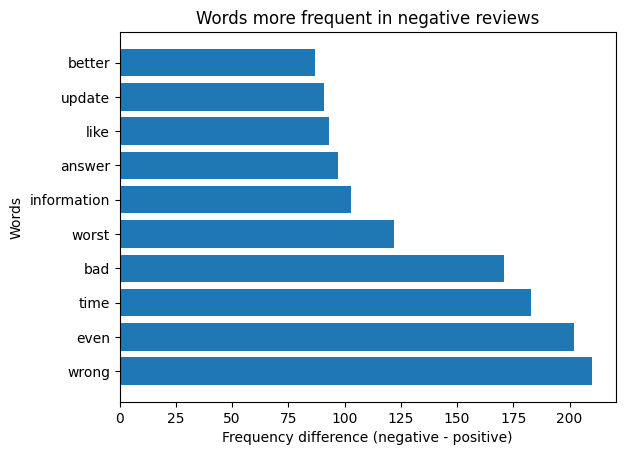

In [ ]:
import matplotlib.pyplot as plt # импортируем библиотеку для построения графиков

plt.figure() # создаём новую фигуру

plt.barh(top_neg['word'], top_neg['diff']) # строим горизонтальный бар-чарт для негативных слов
plt.title("Words more frequent in negative reviews") # задаём заголовок графика
plt.xlabel("Frequency difference (negative - positive)") # подпись оси X
plt.ylabel("Words") # подпись оси Y

plt.show() # отображаем график

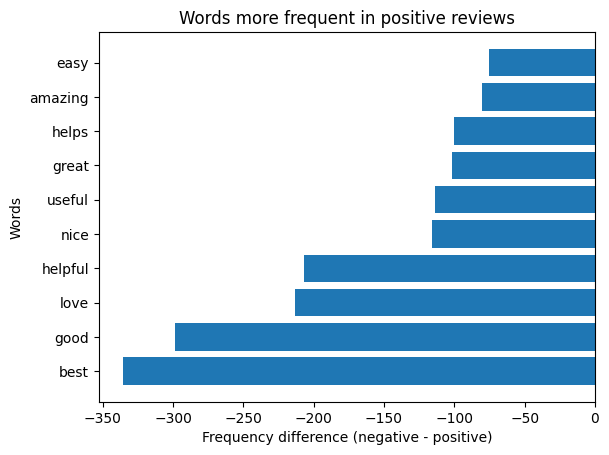

In [ ]:
plt.figure() # создаём новую фигуру

plt.barh(top_pos['word'], top_pos['diff']) # строим горизонтальный бар-чарт для позитивных слов
plt.title("Words more frequent in positive reviews") # задаём заголовок графика
plt.xlabel("Frequency difference (negative - positive)") # подпись оси X
plt.ylabel("Words") # подпись оси Y

plt.show() # отображаем график

Смотрим какие прилагательные чаще всего встречаются, использую библиотеку spacy
python3 -m spacy download en_core_web_sm

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm") # загружаем английскую языковую модель

def get_adjectives(text):
    doc = nlp(text) # обрабатываем текст моделью
    return [token.text for token in doc if token.pos_ == "ADJ"] # возвращаем прилагательные из текста

In [ ]:
df['adjectives'] = df['content'].apply(get_adjectives) # извлекаем прилагательные из текста и сохраняем в новый столбец

In [ ]:
from collections import Counter # импортируем класс для подсчёта частот

neg_adj = [] # список для прилагательных негативных отзывов
pos_adj = [] # список для прилагательных позитивных отзывов

for adjs, label in zip(df['adjectives'], df['label']): # проходим по прилагательным и меткам
    if label == 'negative': 
        neg_adj.extend(adjs) # добавляем в негативный список
    else:
        pos_adj.extend(adjs) # добавляем в позитивный список

print(Counter(neg_adj).most_common(15)) # выводим топ-15 прилагательных (негатив)
print(Counter(pos_adj).most_common(15)) # выводим топ-15 прилагательных (позитив)

[('wrong', 221), ('good', 218), ('bad', 169), ('better', 103), ('worst', 99), ('more', 93), ('free', 89), ('many', 88), ('same', 87), ('new', 70), ('other', 67), ('annoying', 67), ('frustrating', 63), ('worse', 60), ('stupid', 59)]
[('good', 486), ('best', 335), ('helpful', 246), ('useful', 149), ('nice', 141), ('great', 108), ('amazing', 82), ('easy', 73), ('more', 56), ('other', 44), ('many', 43), ('perfect', 34), ('awesome', 33), ('better', 32), ('new', 31)]


Посмотрим на частоты прилагательных

In [ ]:
#from collections import Counter

#neg_adj = []
#pos_adj = []

#for adjs, label in zip(df['adjectives'], df['label']):
#    if label == 'negative':
#        neg_adj.extend(adjs)
#    else:
#        pos_adj.extend(adjs)

#neg_adj_freq = Counter(neg_adj)
#pos_adj_freq = Counter(pos_adj)

In [ ]:
noise_adj = {'other', 'much', 'many', 'same'} # задаём список прилагательных-шума

neg_adj_clean = Counter({k: v for k, v in neg_adj_freq.items() if k not in noise_adj}) # убираем шум из негативных прилагательных
pos_adj_clean = Counter({k: v for k, v in pos_adj_freq.items() if k not in noise_adj}) # убираем шум из позитивных прилагательных

In [ ]:
import pandas as pd

all_adj = set(neg_adj_clean.keys()).union(set(pos_adj_clean.keys())) # объединяем все уникальные прилагательные

rows = []

for word in all_adj:
    neg = neg_adj_clean.get(word, 0) # частота в негативе (или 0)
    pos = pos_adj_clean.get(word, 0) # частота в позитиве (или 0)
    rows.append((word, neg, pos)) # добавляем строку

df_adj = pd.DataFrame(rows, columns=['word', 'neg', 'pos']) # создаём DataFrame
df_adj['diff'] = df_adj['neg'] - df_adj['pos'] # считаем разницу частот

In [ ]:
top_neg_adj = df_adj.sort_values(by='diff', ascending=False).head(10) # топ-10 прилагательных с перевесом в негативе
top_pos_adj = df_adj.sort_values(by='diff').head(10) # топ-10 прилагательных с перевесом в позитиве

top_neg_adj = top_neg_adj.sort_values(by='diff') # сортируем негативный топ для удобного отображения
top_pos_adj = top_pos_adj.sort_values(by='diff') # сортируем позитивный топ для удобного отображения

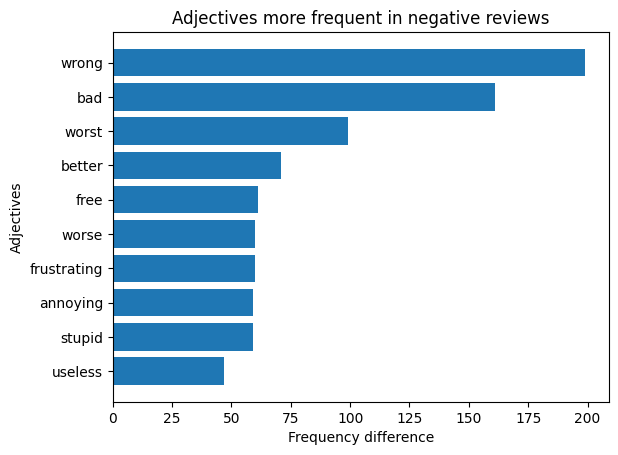

In [ ]:
import matplotlib.pyplot as plt # импортируем библиотеку для графиков

plt.figure() # создаём новую фигуру
plt.barh(top_neg_adj['word'], top_neg_adj['diff']) # строим график для негативных прилагательных
plt.title("Adjectives more frequent in negative reviews") # заголовок
plt.xlabel("Frequency difference") # подпись оси X
plt.ylabel("Adjectives") # подпись оси Y
plt.show() # показываем график

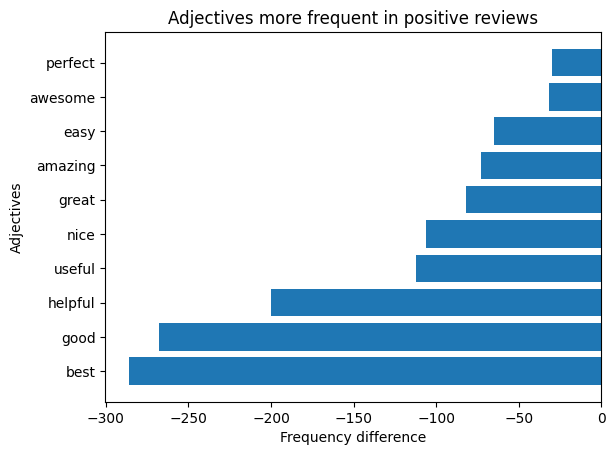

In [ ]:
plt.figure() # создаём новую фигуру
plt.barh(top_pos_adj['word'], top_pos_adj['diff']) # строим график для позитивных прилагательных
plt.title("Adjectives more frequent in positive reviews") # заголовок
plt.xlabel("Frequency difference") # подпись оси X
plt.ylabel("Adjectives") # подпись оси Y
plt.show() 

Посмотрим на биграмы с wrong

In [ ]:
from collections import Counter
from nltk.util import ngrams # импортируем функцию для создания n-грамм

wrong_bigrams = [] # список для биграмм со словом 'wrong'

for tokens in df[df['label']=='negative']['tokens']: # берём токены только из негативных отзывов
    bigrams = list(ngrams(tokens, 2)) # создаём биграммы
    for bg in bigrams:
        if 'wrong' in bg:
            wrong_bigrams.append(bg) # сохраняем биграммы, содержащие 'wrong'

Counter(wrong_bigrams).most_common(15) # выводим топ-15 таких биграмм

[(('wrong', 'answers'), 36),
 (('wrong', 'information'), 32),
 (('wrong', 'answer'), 29),
 (('gives', 'wrong'), 29),
 (('give', 'wrong'), 13),
 (('giving', 'wrong'), 9),
 (('wrong', 'even'), 6),
 (('information', 'wrong'), 6),
 (('gave', 'wrong'), 6),
 (('answer', 'wrong'), 5),
 (('tell', 'wrong'), 5),
 (('tells', 'wrong'), 5),
 (('answers', 'wrong'), 5),
 (('wrong', 'things'), 5),
 (('much', 'wrong'), 4)]

In [ ]:
contexts = []

for tokens in df[df['label']=='negative']['tokens']:
    for i, word in enumerate(tokens): # берём токены негативных отзывов
        if word == 'wrong':
            left = tokens[i-1] if i > 0 else None # слово слева (если есть)
            right = tokens[i+1] if i < len(tokens)-1 else None # слово справа (если есть)
            contexts.append((left, 'wrong', right)) # сохраняем контекст

Counter(contexts).most_common(15) # выводим топ-15 самых частых контекстов

[(('gives', 'wrong', 'answers'), 10),
 (('gives', 'wrong', 'information'), 9),
 (('give', 'wrong', 'information'), 5),
 (('gives', 'wrong', 'answer'), 5),
 (('giving', 'wrong', 'answer'), 4),
 (('many', 'wrong', 'answers'), 4),
 (('giving', 'wrong', 'answers'), 3),
 (('give', 'wrong', 'answers'), 3),
 (('gave', 'wrong', 'answer'), 3),
 (('provide', 'wrong', 'information'), 2),
 (('give', 'wrong', 'answer'), 2),
 (('provides', 'wrong', 'information'), 2),
 (('tell', 'wrong', 'answer'), 2),
 ((None, 'wrong', 'things'), 2),
 (('lot', 'wrong', 'information'), 2)]

Посмотрим на контекст со словом bad

In [ ]:
contexts_bad = [] # список для контекстов слова 'bad'

for tokens in df[df['label']=='negative']['tokens']: # берём токены негативных отзывов
    for i, word in enumerate(tokens): # проходим по словам с индексами
        if word == 'bad':
            left = tokens[i-1] if i > 0 else None # слово слева (если есть)
            right = tokens[i+1] if i < len(tokens)-1 else None  # слово справа (если есть)
            contexts_bad.append((left, 'bad', right)) # сохраняем контекст

from collections import Counter # импортируем Counter
Counter(contexts_bad).most_common(15) # выводим топ-15 частых контекстов

[((None, 'bad', 'app'), 15),
 ((None, 'bad', 'experience'), 7),
 ((None, 'bad', 'working'), 2),
 (('app', 'bad', 'app'), 2),
 ((None, 'bad', 'ask'), 2),
 ((None, 'bad', 'environment'), 2),
 (('soo', 'bad', 'soo'), 2),
 (('app', 'bad', 'values'), 1),
 (('lead', 'bad', 'decisions'), 1),
 ((None, 'bad', 'sharing'), 1),
 (('rovient', 'bad', 'experience'), 1),
 ((None, 'bad', 'doen'), 1),
 (('fell', 'bad', 'generates'), 1),
 (('quality', 'bad', 'ton'), 1),
 (('good', 'bad', 'hate'), 1)]

In [ ]:
from nltk.util import ngrams # импортируем функцию для создания n-грамм

bad_bigrams = [] # список для биграмм со словом 'bad'

for tokens in df[df['label']=='negative']['tokens']: # берём токены негативных отзывов 
    for bg in ngrams(tokens, 2): # создаём биграммы (пары слов)
        if 'bad' in bg:
            bad_bigrams.append(bg) # сохраняем биграммы, содержащие 'bad'

Counter(bad_bigrams).most_common(15) # выводим топ-15 таких биграмм

[(('bad', 'app'), 20),
 (('app', 'bad'), 12),
 (('bad', 'experience'), 9),
 (('really', 'bad'), 5),
 (('bad', 'information'), 5),
 (('bad', 'even'), 5),
 (('gotten', 'bad'), 4),
 (('good', 'bad'), 3),
 (('bad', 'environment'), 3),
 (('bad', 'thing'), 3),
 (('bad', 'ai'), 3),
 (('chatgpt', 'bad'), 3),
 (('bad', 'always'), 3),
 (('bad', 'hate'), 2),
 (('users', 'bad'), 2)]

Посмотрим на frunstrating

In [60]:
contexts_fr = []

for tokens in df[df['label']=='negative']['tokens']:
    for i, word in enumerate(tokens):
        if word == 'frustrating':
            left = tokens[i-1] if i > 0 else None
            right = tokens[i+1] if i < len(tokens)-1 else None
            contexts_fr.append((left, 'frustrating', right))

from collections import Counter
Counter(contexts_fr).most_common(15)

[((None, 'frustrating', 'experience'), 2),
 (('question', 'frustrating', 'regenerate'), 1),
 (('resources', 'frustrating', 'one'), 1),
 (('confidence', 'frustrating', 'makes'), 1),
 (('honestly', 'frustrating', 'like'), 1),
 (('immediately', 'frustrating', 'pay'), 1),
 (('much', 'frustrating', 'app'), 1),
 ((None, 'frustrating', 'app'), 1),
 (('extremely', 'frustrating', 'use'), 1),
 (('lately', 'frustrating', 'experience'), 1),
 (('short', 'frustrating', 'instead'), 1),
 ((None, 'frustrating', 'constantly'), 1),
 (('useless', 'frustrating', 'app'), 1),
 (('glitches', 'frustrating', 'unreliable'), 1),
 (('extremely', 'frustrating', 'currently'), 1)]

In [61]:
from nltk.util import ngrams

fr_bigrams = []

for tokens in df[df['label']=='negative']['tokens']:
    for bg in ngrams(tokens, 2):
        if 'frustrating' in bg:
            fr_bigrams.append(bg)

Counter(fr_bigrams).most_common(15)

[(('frustrating', 'app'), 5),
 (('frustrating', 'experience'), 5),
 (('extremely', 'frustrating'), 5),
 (('experience', 'frustrating'), 5),
 (('frustrating', 'use'), 4),
 (('really', 'frustrating'), 4),
 (('honestly', 'frustrating'), 2),
 (('frustrating', 'like'), 2),
 (('frustrating', 'pay'), 2),
 (('frustrating', 'instead'), 2),
 (('frustrating', 'time'), 2),
 (('also', 'frustrating'), 2),
 (('chatgpt', 'frustrating'), 2),
 (('completely', 'frustrating'), 2),
 (('frustrating', 'tone'), 2)]

Посмотрим на глаголы

In [ ]:
def get_verbs(text):
    doc = nlp(text) # обрабатываем текст моделью
    return [token.text for token in doc if token.pos_ == "VERB"] # возвращаем глаголы из текста

In [ ]:
df['verbs'] = df['content'].apply(get_verbs) # извлекаем глаголы и сохраняем в новый столбец

In [ ]:
from collections import Counter # импортируем класс для подсчёта частот

neg_verbs = [] 
pos_verbs = []

for verbs, label in zip(df['verbs'], df['label']):
    if label == 'negative':
        neg_verbs.extend(verbs) # добавляем в негативный список
    else:
        pos_verbs.extend(verbs) # добавляем в позитивный список

neg_v_freq = Counter(neg_verbs) # считаем частоты глаголов (негатив)
pos_v_freq = Counter(pos_verbs) # считаем частоты глаголов (позитив)

print("Negative:", neg_v_freq.most_common(15)) # выводим топ-15 глаголов (негатив)
print("Positive:", pos_v_freq.most_common(15)) # выводим топ-15 глаголов (позитив)

Negative: [('use', 201), ('have', 177), ('do', 153), ('give', 148), ('want', 132), ('get', 118), ('using', 117), ('ask', 117), ('make', 109), ('say', 103), ('gives', 102), ('used', 90), ('pay', 83), ('know', 77), ('need', 76)]
Positive: [('love', 200), ('use', 140), ('helps', 108), ('help', 100), ('like', 92), ('have', 92), ('give', 79), ('make', 61), ('want', 59), ('using', 50), ('get', 49), ('know', 48), ('need', 45), ('gives', 44), ('thank', 43)]


убираем глаголы недающие смысла

In [65]:
noise_verbs = {'use', 'have', 'do', 'get', 'make', 'know', 'using', 'used'}

neg_v_clean = Counter({k: v for k, v in neg_v_freq.items() if k not in noise_verbs})
pos_v_clean = Counter({k: v for k, v in pos_v_freq.items() if k not in noise_verbs})

print("Negative:", neg_v_clean.most_common(15))
print("Positive:", pos_v_clean.most_common(15))

Negative: [('give', 148), ('want', 132), ('ask', 117), ('say', 103), ('gives', 102), ('pay', 83), ('need', 76), ('fix', 75), ('asked', 74), ('giving', 72), ('working', 70), ('send', 66), ('tell', 66), ('keeps', 65), ('said', 64)]
Positive: [('love', 200), ('helps', 108), ('help', 100), ('like', 92), ('give', 79), ('want', 59), ('need', 45), ('gives', 44), ('thank', 43), ('ask', 39), ('helped', 39), ('think', 37), ('understand', 36), ('try', 32), ('has', 31)]


In [ ]:
target_words = ['want', 'need', 'fix'] # задаём целевые слова

contexts = []

for tokens in df[df['label']=='negative']['tokens']: # берём токены негативных отзывов
    for i, word in enumerate(tokens):
        if word in target_words:
            window = tokens[max(0, i-2): i+3]  # контекст ±2
            contexts.append(window)

contexts[:10]

[['app', 'download', 'want', 'waste', 'time'],
 ['want', 'delet', 'account'],
 ['need', 'ai', 'ts'],
 ['app', 'either', 'fix', 'problem', 'refund'],
 ['help', 'way', 'want'],
 ['buggy', 'opinion', 'fix', 'maybe', 'try'],
 ['start', 'makes', 'want', 'use', 'less'],
 ['close', 'clearly', 'need', 'still', 'laughing'],
 ['galaxy', 'ultra', 'fix', 'already'],
 ['real', 'please', 'fix']]

In [67]:
for c in contexts[:20]:
    print(' '.join(c))

app download want waste time
want delet account
need ai ts
app either fix problem refund
help way want
buggy opinion fix maybe try
start makes want use less
close clearly need still laughing
galaxy ultra fix already
real please fix
creating dont want still count
let talk want talk interrupt
getting really want instead extracting
im minor fix guide bot
active please fix sync issue
projects please fix download open
need say ai
lag maybe fix problem people
want subscription means
good need pay upload


In [ ]:
from nltk.util import ngrams
from collections import Counter

bigrams = [] # список для биграмм

for tokens in df[df['label']=='negative']['tokens']: 
    for bg in ngrams(tokens, 2):
        if any(w in bg for w in target_words): 
            bigrams.append(bg) # сохраняем биграммы с целевыми словами

Counter(bigrams).most_common(20)

[(('please', 'fix'), 32),
 (('need', 'pay'), 8),
 (('want', 'use'), 7),
 (('want', 'give'), 7),
 (('need', 'upgrade'), 6),
 (('fix', 'problem'), 5),
 (('really', 'need'), 5),
 (('dont', 'want'), 4),
 (('really', 'want'), 4),
 (('want', 'make'), 4),
 (('fix', 'make'), 4),
 (('want', 'get'), 4),
 (('want', 'upgrade'), 4),
 (('need', 'say'), 3),
 (('even', 'want'), 3),
 (('give', 'want'), 3),
 (('want', 'know'), 3),
 (('want', 'something'), 3),
 (('limit', 'need'), 3),
 (('fix', 'bug'), 3)]

изучим отзывы в которых есть actinable request

In [ ]:
action_verbs = {'fix', 'update', 'add', 'improve'} # глаголы действий
request_words = {'please', 'need'} # слова-запросы

In [70]:
def is_actionable(tokens):
    for i, word in enumerate(tokens):
        
        # паттерн 1: fix / update / add
        if word in action_verbs:
            return True
        
        # паттерн 2: please + verb
        if word == 'please' and i < len(tokens) - 1:
            return True
        
        # паттерн 3: need + verb
        if word == 'need' and i < len(tokens) - 1:
            return True
    
    return False

In [71]:
df['actionable'] = df['tokens'].apply(is_actionable)

In [72]:
df['actionable'].value_counts()

actionable
False    4191
True      429
Name: count, dtype: int64

In [73]:
df[df['actionable'] == True]['content'].sample(10, random_state=42)

4455    I'm new to and tentative with AI, and so far, ...
588     cant find add details and think more options f...
1338    You have given wrong information of Sourashtra...
235     this app is not perfect this app provides wron...
3230    4 stars only because I'm writing a story and w...
2026    need more improvements just a basic informatio...
1173                   he is asking for more update wrong
1167    i have problem that you did not fix if we make...
1239              it have to improve by seeing deepseek 😇
1314                 do I really need to say anything....
Name: content, dtype: object

In [74]:
df[df['label']=='negative']['actionable'].mean()

np.float64(0.13463203463203463)

In [ ]:
feedback_dict = {
    'error': ['wrong', 'incorrect', 'false'], # слова, связанные с ошибками
    'bug': ['bug', 'crash', 'error', 'fix'], # слова, связанные с багами
    'request': ['need', 'want', 'add', 'improve', 'update'], # слова-запросы на улучшение
    'pricing': ['pay', 'subscription', 'upgrade', 'free'], # слова про оплату
    'ux': ['frustrating', 'annoying', 'slow'] # слова про неудобство использования
}

In [76]:
def classify_feedback(tokens):
    categories = set()
    
    for word in tokens:
        for cat, keywords in feedback_dict.items():
            if word in keywords:
                categories.add(cat)
    
    return list(categories)

In [77]:
df['feedback_type'] = df['tokens'].apply(classify_feedback)

In [78]:
from collections import Counter

all_types = []

for types in df[df['label']=='negative']['feedback_type']:
    all_types.extend(types)

Counter(all_types)

Counter({'request': 307, 'error': 254, 'pricing': 253, 'ux': 153, 'bug': 104})

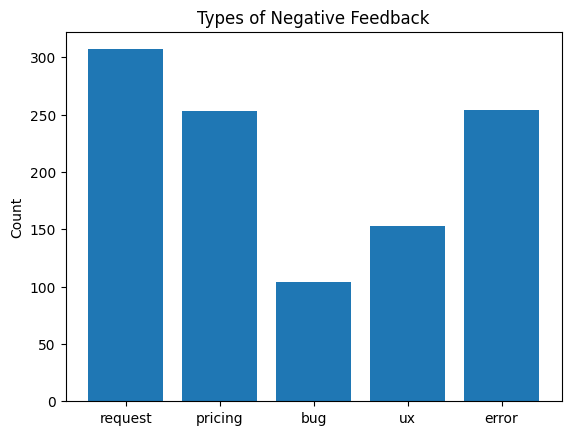

In [80]:
counts = Counter(all_types)

plt.figure()
plt.bar(counts.keys(), counts.values())
plt.title("Types of Negative Feedback")
plt.ylabel("Count")

plt.show()

In [83]:
df[df['label']=='negative'][['content', 'feedback_type']].head(10)

,content,feedback_type
0,"I would give this 5 star, but one key flaw it ...",[]
1,This is a completely useless app. Don't downlo...,[request]
2,used to be good and helpful but it is now all ...,[pricing]
3,fi7dhc 88 is le ga tx existing seats height ya...,[]
4,when I needed it most it says you have reached...,[]
5,gone significantly downhill since the early da...,[]
6,every time an error pops up,[bug]
7,has a limit access to send pictures and needed...,[pricing]
8,I am just starting to use and say the limit is...,[]
9,I couldn't download the P.D.F and others that ...,[]


In [84]:
df[df['feedback_type'].apply(lambda x: 'bug' in x)][['content']].head(10)

,content
6,every time an error pops up
24,terrible i can't save or retrieve any of the s...
52,Huge issues with the app freezing while trying...
63,Voice recognition gets worse every day with th...
77,continue with google keeps in loading state fo...
92,very greedy. used to be able to add 10 photos....
147,Why is the edit button only for 18+ now? 😭 I l...
150,I’m giving 2 stars because I was automatically...
151,I’m experiencing a serious issue in the Androi...
195,I love the app at all for the whole update abo...


Посмотрим пересечения

In [85]:
df[df['feedback_type'].apply(lambda x: 'bug' in x and 'request' in x)][['content']].head(10)

,content
63,Voice recognition gets worse every day with th...
92,very greedy. used to be able to add 10 photos....
195,I love the app at all for the whole update abo...
216,it was good but I need to pay to upload images...
314,please update your software lot of error
629,the app been crashing and glitching more after...
773,"ChatGPT is helpful at times, but it repeatedly..."
776,I am giving it 0 but I can't add 0 stars becau...
831,Forget the update to fix a bug that affects de...
1129,It was good at first and then suddenly it star...


In [86]:
df[(df['actionable']==True) & (df['label']=='negative')][['content', 'feedback_type']].head(10)

,content,feedback_type
13,the app is consistently update but there's alw...,"[request, ux]"
16,"we don't need ai, ts is consuming sm water and...",[request]
24,terrible i can't save or retrieve any of the s...,"[pricing, bug]"
32,After the update start giving the wrong answer,"[request, error]"
50,"Was great until updates ruined it, like EVERYT...",[request]
52,Huge issues with the app freezing while trying...,[bug]
55,please do not install the app,[]
63,Voice recognition gets worse every day with th...,"[request, pricing, bug]"
75,constantly changing answers and not accepting ...,[request]
77,continue with google keeps in loading state fo...,[bug]


In [87]:
df.to_csv('reviews_with_labels.csv', index=False)